<h3 style="color: #e0e0ff; font-style: italic;">🔍 Comparative Evaluation of CLIP Variants</h3>

We evaluate 7 distinct configurations to identify the best performing backbone for our dataset:

---

1. **OpenAI CLIP**: `openai/clip-vit-base-patch16` + MLP
2. **SigLIP**: `google/siglip-base-patch16-256-multilingual` + MLP
3. **MetaCLIP**: `ViT-B-16` / `metaclip_400m` + MLP
4. **Jina CLIP**: `jinaai/jina-clip-v1` + MLP
5. **OpenCLIP**: `ViT-B-16` / `laion2b_s34b_b79k` + MLP
6. **EVA-CLIP**: `EVA01-CLIP-g-14` / `laion2b_s34b_b79k` + MLP
7. **DINOv2 + XLM-RoBERTa**: `dinov2_vits14` + `xlm-roberta-base` + MLP

**Imports and Setup**

In [1]:
# Core
import time
import os
import sys
from PIL import Image
from tqdm import tqdm

# Data manipulation
import numpy as np
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# Transformers
from transformers import (
    CLIPProcessor, CLIPModel,
    AutoProcessor, SiglipModel,
    AutoModel,
    XLMRobertaModel, XLMRobertaTokenizer
)
import open_clip

# sklearn
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    roc_curve, auc, roc_auc_score, precision_recall_fscore_support
)

import warnings
warnings.filterwarnings('ignore')

# Setup paths
sys.path.insert(0, os.path.abspath("../src"))
from data_pipeline import M4FCDataPipeline
from model_registry import update_registry

c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Device & reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Device: {device}")

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
set_seed(42)

# Output directories
os.makedirs('../models/clip', exist_ok=True)
os.makedirs('../reports/clip/figures', exist_ok=True)
os.makedirs('../reports/clip/metrics', exist_ok=True)
sns.set_palette("husl")

🚀 Device: cuda


**Dataset Classes**

In [3]:
class M4FCRawDataset(Dataset):
    """Dataset for raw image+text loading through a CLIP-style processor."""
    def __init__(self, df, processor, max_text_length=77, is_open_clip=False):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.max_text_length = max_text_length
        self.is_open_clip = is_open_clip
        self.text_field = 'multilingual_claim'
        
    def __len__(self):
        return len(self.df)
        
    def load_image(self, image_path):
        try:
            if os.path.exists(image_path):
                return Image.open(image_path).convert('RGB')
        except Exception:
            pass
        return Image.new('RGB', (224, 224), (0, 0, 0))
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row[self.text_field]) if pd.notna(row[self.text_field]) else " "
        if not text.strip():
            text = " "
            
        image_path = row['full_image_path'] if pd.notna(row['full_image_path']) else ""
        image = self.load_image(image_path)
        label = torch.tensor(row['target'], dtype=torch.long)
        
        if self.is_open_clip:
            inputs = self.processor(text, image, max_length=self.max_text_length)
            return {
                'pixel_values': inputs['pixel_values'].squeeze(0),
                'input_ids': inputs['input_ids'].squeeze(0),
                'label': label
            }
        else:
            inputs = self.processor(
                text=[text],
                images=image,
                return_tensors="pt",
                padding="max_length",
                truncation=True,
                max_length=self.max_text_length
            )
            batch = {
                'pixel_values': inputs['pixel_values'].squeeze(0),
                'input_ids': inputs['input_ids'].squeeze(0),
                'label': label
            }
            if 'attention_mask' in inputs:
                batch['attention_mask'] = inputs['attention_mask'].squeeze(0)
            return batch

In [4]:
class PreExtractedDataset(Dataset):
    """Dataset for pre-extracted image/text feature tensors."""
    def __init__(self, img_feats, txt_feats, labels):
        assert len(img_feats) == len(txt_feats) == len(labels)
        self.img_feats = img_feats
        self.txt_feats = txt_feats
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return {
            'img_feats': self.img_feats[idx],
            'txt_feats': self.txt_feats[idx],
            'label': self.labels[idx]
        }

**Classifier & Fusion Architecture**

In [5]:
class FakeNewsClassifier(nn.Module):
    def __init__(self, image_dim, text_dim, num_classes=2):
        super().__init__()
        self.fusion_layer = nn.Sequential(
            nn.Linear(image_dim + text_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, img_features, text_features):
        img_features = img_features.float()
        text_features = text_features.float()
        # L2-normalize before concat
        img_features = img_features / (img_features.norm(dim=-1, keepdim=True) + 1e-8)
        text_features = text_features / (text_features.norm(dim=-1, keepdim=True) + 1e-8)
        combined = torch.cat((img_features, text_features), dim=1)
        return self.fusion_layer(combined)

**Standardized CLIP Trainer**

In [6]:
class CLIPTrainer:
    """Unified trainer for all CLIP variants — supports both raw-image and pre-extracted-feature loaders."""

    def __init__(self, model, backbone, train_loader, val_loader, test_loader,
                 device='cuda', backbone_api='huggingface', save_name='CLIP',
                 early_stopping_patience=10, pre_extracted=False):
        self.model = model.to(device)
        self.backbone = backbone.to(device) if backbone is not None else None
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        self.backbone_api = backbone_api
        self.save_name = save_name
        self.early_stopping_patience = early_stopping_patience
        self.pre_extracted = pre_extracted  # if True: loader yields img_feats/txt_feats directly

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=1e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=20)

        # Class-weighted loss
        num_real, num_fake = 0, 0
        for batch in self.train_loader:
            lbls = batch['label'] if isinstance(batch, dict) else batch[-1]
            num_real += (lbls == 0).sum().item()
            num_fake += (lbls == 1).sum().item()
        weight_real = 1.0 / num_real if num_real > 0 else 1.0
        weight_fake = 1.0 / num_fake if num_fake > 0 else 1.0
        weights = torch.tensor([weight_real, weight_fake], dtype=torch.float).to(device)
        weights = weights / weights.sum()
        self.criterion = nn.CrossEntropyLoss(weight=weights)

        self.metrics_history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'precision': [], 'recall': [], 'f1': [], 'auc': []
        }
        self.best_val_f1 = 0.0
        self.best_val_acc = 0.0
        self.best_model_path = f"../models/clip/{save_name}_classifier_best.pth"
        os.makedirs(os.path.dirname(self.best_model_path), exist_ok=True)

    def _extract_features(self, batch):
        """Extract image/text features from a batch (handles both raw and pre-extracted modes)."""
        if self.pre_extracted:
            return batch['img_feats'].to(self.device), batch['txt_feats'].to(self.device)

        pixel_values = batch['pixel_values'].to(self.device)
        input_ids = batch['input_ids'].to(self.device)
        mask = batch.get('attention_mask')
        if mask is not None:
            mask = mask.to(self.device)

        if self.backbone_api == "open_clip":
            img_feats = self.backbone.encode_image(pixel_values).float()
            txt_feats = self.backbone.encode_text(input_ids).float()
        else:  # huggingface
            outputs = self.backbone(pixel_values=pixel_values, input_ids=input_ids, attention_mask=mask)
            img_feats = outputs.image_embeds.float()
            txt_feats = outputs.text_embeds.float()

        return img_feats, txt_feats

    def train_epoch(self):
        self.model.train()
        if self.backbone is not None:
            self.backbone.eval()
        total_loss, predictions, labels = 0, [], []

        for batch in self.train_loader:
            label = batch['label'].to(self.device)

            with torch.no_grad():
                img_feats, txt_feats = self._extract_features(batch)

            self.optimizer.zero_grad()
            logits = self.model(img_feats, txt_feats)
            loss = self.criterion(logits, label)
            loss.backward()
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item()
            _, preds = torch.max(logits, 1)
            predictions.extend(preds.cpu().numpy())
            labels.extend(label.cpu().numpy())

        self.scheduler.step()
        return total_loss / len(self.train_loader), accuracy_score(labels, predictions)

    @torch.no_grad()
    def evaluate(self, data_loader, mode='val'):
        self.model.eval()
        if self.backbone is not None:
            self.backbone.eval()
        total_loss, predictions, probabilities, labels = 0, [], [], []

        for batch in data_loader:
            label = batch['label'].to(self.device)
            img_feats, txt_feats = self._extract_features(batch)

            logits = self.model(img_feats, txt_feats)
            loss = self.criterion(logits, label)

            total_loss += loss.item()
            probs = F.softmax(logits, dim=1)
            _, preds = torch.max(logits, 1)
            predictions.extend(preds.cpu().numpy())
            probabilities.extend(probs[:, 1].cpu().numpy())
            labels.extend(label.cpu().numpy())

        precision, recall, f1, _ = precision_recall_fscore_support(
            labels, predictions, average='binary', zero_division=0
        )
        try:
            auc_score = roc_auc_score(labels, probabilities)
        except Exception:
            auc_score = 0.5

        return {
            'loss': total_loss / len(data_loader),
            'accuracy': accuracy_score(labels, predictions),
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc_score,
            'predictions': predictions,
            'true_labels': labels,
            'probabilities': probabilities
        }

    def train(self, epochs=20):
        print(f"\n🚀 Training {self.save_name}...")
        patience_counter = 0

        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch()
            val_metrics = self.evaluate(self.val_loader, 'val')

            self.metrics_history['train_loss'].append(train_loss)
            self.metrics_history['train_acc'].append(train_acc)
            self.metrics_history['val_loss'].append(val_metrics['loss'])
            self.metrics_history['val_acc'].append(val_metrics['accuracy'])
            self.metrics_history['precision'].append(val_metrics['precision'])
            self.metrics_history['recall'].append(val_metrics['recall'])
            self.metrics_history['f1'].append(val_metrics['f1'])
            self.metrics_history['auc'].append(val_metrics['auc'])

            print(f"Epoch {epoch+1:>3}/{epochs} | Loss: {train_loss:.4f} | Val F1: {val_metrics['f1']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")

            if val_metrics['f1'] > self.best_val_f1:
                self.best_val_f1 = val_metrics['f1']
                self.best_val_acc = val_metrics['accuracy']
                patience_counter = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'val_f1': val_metrics['f1'],
                    'val_accuracy': val_metrics['accuracy']
                }, self.best_model_path)
                print(f"  🏆 Best model saved: Val F1={val_metrics['f1']:.4f}")
            else:
                patience_counter += 1
                if patience_counter >= self.early_stopping_patience:
                    print(f"  🛑 Early stopping triggered at epoch {epoch+1}")
                    break

        return self.metrics_history

    def test(self):
        print(f"\n📊 Evaluating {self.save_name} on test set...")
        if os.path.exists(self.best_model_path):
            checkpoint = torch.load(self.best_model_path, weights_only=False)
            self.model.load_state_dict(checkpoint['model_state_dict'])

        start_time = time.time()
        test_metrics = self.evaluate(self.test_loader, 'test')
        test_metrics['inference_time'] = time.time() - start_time

        print(f"Accuracy: {test_metrics['accuracy']:.4f} | F1: {test_metrics['f1']:.4f} | AUC: {test_metrics['auc']:.4f}")
        return test_metrics


**Visualizer & Reporting**

In [7]:
class CLIPVisualizer:
    @staticmethod
    def plot_all(metrics_history, test_metrics, save_name):
        fig_dir = f"../reports/clip/figures/{save_name}"
        os.makedirs(fig_dir, exist_ok=True)

        # 1. Training History
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes[0, 0].plot(metrics_history['train_loss'], label='Train Loss')
        axes[0, 0].plot(metrics_history['val_loss'], label='Val Loss')
        axes[0, 0].set_title('Loss'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

        axes[0, 1].plot(metrics_history['train_acc'], label='Train Acc')
        axes[0, 1].plot(metrics_history['val_acc'], label='Val Acc')
        axes[0, 1].set_title('Accuracy'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

        axes[1, 0].plot(metrics_history['f1'], label='F1', marker='o')
        axes[1, 0].plot(metrics_history['auc'], label='AUC', marker='s')
        axes[1, 0].set_title('F1 & AUC'); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

        axes[1, 1].plot(metrics_history['precision'], label='Precision', marker='^')
        axes[1, 1].plot(metrics_history['recall'], label='Recall', marker='v')
        axes[1, 1].set_title('Precision-Recall'); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(fig_dir, 'training_history.png'), dpi=100)
        plt.close()

        # 2. Confusion Matrix
        cm = confusion_matrix(test_metrics['true_labels'], test_metrics['predictions'])
        plt.figure(figsize=(7, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
        plt.title(f'Confusion Matrix - {save_name}')
        plt.ylabel('True'); plt.xlabel('Predicted')
        plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'), dpi=100)
        plt.close()

        # 3. ROC Curve
        fpr, tpr, _ = roc_curve(test_metrics['true_labels'], test_metrics['probabilities'])
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, color='purple', lw=2, label=f'AUC = {roc_auc:.3f}')
        plt.plot([0, 1], [0, 1], '--', color='navy')
        plt.title(f'ROC Curve - {save_name}')
        plt.xlabel('FPR'); plt.ylabel('TPR')
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(fig_dir, 'roc_curve.png'), dpi=100)
        plt.close()

        print(f"✅ All plots saved to {fig_dir}")

In [8]:
class CLIPModelSaver:
    @staticmethod
    def generate_report(metrics_history, test_metrics, save_name):
        report_path = f"../reports/clip/metrics/{save_name}_Report.txt"
        os.makedirs(os.path.dirname(report_path), exist_ok=True)

        best_val_f1 = max(metrics_history['f1']) if metrics_history['f1'] else test_metrics['f1']
        best_val_acc = max(metrics_history['val_acc']) if metrics_history['val_acc'] else test_metrics['accuracy']

        with open(report_path, 'w', encoding='utf-8') as f:
            f.write("=" * 60 + "\n")
            f.write(f"{save_name} MODEL FAKE NEWS DETECTION REPORT\n")
            f.write("=" * 60 + "\n\n")
            f.write(f"Epochs completed: {len(metrics_history['train_loss'])}\n")
            f.write(f"Best Val F1:   {best_val_f1:.6f}\n")
            f.write(f"Best Val Acc:  {best_val_acc:.6f}\n\n")
            f.write("TEST SET RESULTS\n")
            f.write("-" * 30 + "\n")
            f.write(f"  Accuracy:  {test_metrics['accuracy']:.6f}\n")
            f.write(f"  Precision: {test_metrics['precision']:.6f}\n")
            f.write(f"  Recall:    {test_metrics['recall']:.6f}\n")
            f.write(f"  F1-Score:  {test_metrics['f1']:.6f}\n")
            f.write(f"  AUC:       {test_metrics['auc']:.6f}\n")
        print(f"✅ Report saved to {report_path}")

        update_registry(
            name=save_name,
            arch="FakeNewsClassifier",
            rel_path=f"models/clip/{save_name}_classifier_best.pth",
            val_accuracy=float(best_val_acc),
            val_f1=float(best_val_f1),
            test_accuracy=float(test_metrics['accuracy']),
            test_f1=float(test_metrics['f1']),
            test_auc=float(test_metrics['auc']),
            num_classes=2
        )

**Data Loading & Common Split (Done Once for All Variants)**

In [9]:
# Load the M4FC dataframe and apply standardized 70/15/15 split
pipeline = M4FCDataPipeline(csv_path='../data/M4FC.csv', target_col='target', random_state=42)
df = pipeline._load_data()
train_df, val_df, test_df = pipeline.split_dataframe(df)

print(f"✓ Dataset split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# Stores results from all variants for final comparison
all_results = {}

✓ Dataset split: Train=3462, Val=743, Test=743


### 1. OpenAI CLIP (`openai/clip-vit-base-patch16`)

In [11]:
SAVE_NAME = "OpenAI_CLIP"
processor_clip = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch16')
backbone_clip = CLIPModel.from_pretrained('openai/clip-vit-base-patch16', use_safetensors=True)
for p in backbone_clip.parameters(): p.requires_grad = False

train_ds = M4FCRawDataset(train_df, processor_clip)
val_ds = M4FCRawDataset(val_df, processor_clip)
test_ds = M4FCRawDataset(test_df, processor_clip)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# Classifier: CLIP image/text embed dim = 512
clf = FakeNewsClassifier(image_dim=512, text_dim=512)
trainer = CLIPTrainer(clf, backbone_clip, train_loader, val_loader, test_loader,
                      device=device, backbone_api='huggingface', save_name=SAVE_NAME, early_stopping_patience=5)

metrics_history = trainer.train(epochs=20)
test_metrics = trainer.test()
all_results[SAVE_NAME] = test_metrics

CLIPVisualizer.plot_all(metrics_history, test_metrics, SAVE_NAME)
CLIPModelSaver.generate_report(metrics_history, test_metrics, SAVE_NAME)


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 2825.37it/s]



🚀 Training OpenAI_CLIP...
Epoch   1/20 | Loss: 0.6578 | Val F1: 0.9685 | Val Acc: 0.9394
  🏆 Best model saved: Val F1=0.9685
Epoch   2/20 | Loss: 0.5963 | Val F1: 0.9707 | Val Acc: 0.9435
  🏆 Best model saved: Val F1=0.9707
Epoch   3/20 | Loss: 0.6152 | Val F1: 0.9714 | Val Acc: 0.9448
  🏆 Best model saved: Val F1=0.9714
Epoch   4/20 | Loss: 0.5990 | Val F1: 0.9714 | Val Acc: 0.9448
Epoch   5/20 | Loss: 0.5962 | Val F1: 0.9707 | Val Acc: 0.9435
Epoch   6/20 | Loss: 0.5659 | Val F1: 0.9714 | Val Acc: 0.9448
Epoch   7/20 | Loss: 0.5889 | Val F1: 0.9707 | Val Acc: 0.9435
Epoch   8/20 | Loss: 0.5800 | Val F1: 0.9707 | Val Acc: 0.9435
  🛑 Early stopping triggered at epoch 8

📊 Evaluating OpenAI_CLIP on test set...
Accuracy: 0.9327 | F1: 0.9649 | AUC: 0.6828
✅ All plots saved to ../reports/clip/figures/OpenAI_CLIP
✅ Report saved to ../reports/clip/metrics/OpenAI_CLIP_Report.txt
ℹ️  Registry unchanged — current champion 'Fusion - Metadata Fusion (MLP)' (acc=0.9462) leads 'OpenAI_CLIP' (acc=0

### 2. SigLIP (`google/siglip-base-patch16-256-multilingual`)

In [13]:
SAVE_NAME = "SigLIP"
processor_siglip = AutoProcessor.from_pretrained('google/siglip-base-patch16-256-multilingual')
backbone_siglip = SiglipModel.from_pretrained('google/siglip-base-patch16-256-multilingual')
for p in backbone_siglip.parameters(): p.requires_grad = False

train_ds = M4FCRawDataset(train_df, processor_siglip, max_text_length=64)
val_ds = M4FCRawDataset(val_df, processor_siglip, max_text_length=64)
test_ds = M4FCRawDataset(test_df, processor_siglip, max_text_length=64)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# SigLIP embed dim = 768
clf = FakeNewsClassifier(image_dim=768, text_dim=768)
trainer = CLIPTrainer(clf, backbone_siglip, train_loader, val_loader, test_loader,
                      device=device, backbone_api='huggingface', save_name=SAVE_NAME, early_stopping_patience=5)

metrics_history = trainer.train(epochs=20)
test_metrics = trainer.test()
all_results[SAVE_NAME] = test_metrics

CLIPVisualizer.plot_all(metrics_history, test_metrics, SAVE_NAME)
CLIPModelSaver.generate_report(metrics_history, test_metrics, SAVE_NAME)


Loading weights: 100%|██████████| 408/408 [00:00<00:00, 3454.85it/s]



🚀 Training SigLIP...
Epoch   1/20 | Loss: 0.6682 | Val F1: 0.9664 | Val Acc: 0.9354
  🏆 Best model saved: Val F1=0.9664
Epoch   2/20 | Loss: 0.6324 | Val F1: 0.9663 | Val Acc: 0.9354
Epoch   3/20 | Loss: 0.5896 | Val F1: 0.9672 | Val Acc: 0.9367
  🏆 Best model saved: Val F1=0.9672
Epoch   4/20 | Loss: 0.6350 | Val F1: 0.9664 | Val Acc: 0.9354
Epoch   5/20 | Loss: 0.5713 | Val F1: 0.9693 | Val Acc: 0.9408
  🏆 Best model saved: Val F1=0.9693
Epoch   6/20 | Loss: 0.5783 | Val F1: 0.9694 | Val Acc: 0.9408
  🏆 Best model saved: Val F1=0.9694
Epoch   7/20 | Loss: 0.5831 | Val F1: 0.9686 | Val Acc: 0.9394
Epoch   8/20 | Loss: 0.5636 | Val F1: 0.9678 | Val Acc: 0.9381
Epoch   9/20 | Loss: 0.6027 | Val F1: 0.9687 | Val Acc: 0.9394
Epoch  10/20 | Loss: 0.5494 | Val F1: 0.9701 | Val Acc: 0.9421
  🏆 Best model saved: Val F1=0.9701
Epoch  11/20 | Loss: 0.5256 | Val F1: 0.9656 | Val Acc: 0.9341
Epoch  12/20 | Loss: 0.5471 | Val F1: 0.9664 | Val Acc: 0.9354
Epoch  13/20 | Loss: 0.5719 | Val F1: 0.96

### 3. MetaCLIP (`ViT-B-16` / `metaclip_400m` via `open_clip`)

In [14]:
class OpenCLIPProcessorWrapper:
    """Wraps open_clip preprocess + tokenizer into a unified callable for M4FCRawDataset."""
    def __init__(self, preprocess_fn, tokenizer, max_length=77):
        self.preprocess_fn = preprocess_fn
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, text, images, max_length=None):
        return {
            'pixel_values': self.preprocess_fn(images).unsqueeze(0),
            'input_ids': self.tokenizer([text], context_length=self.max_length)
        }


In [15]:
SAVE_NAME = "MetaCLIP"
backbone_meta, _, preprocess_meta = open_clip.create_model_and_transforms('ViT-B-16', pretrained='metaclip_400m')
tokenizer_meta = open_clip.get_tokenizer('ViT-B-16')
for p in backbone_meta.parameters(): p.requires_grad = False

proc_meta = OpenCLIPProcessorWrapper(preprocess_meta, tokenizer_meta)
train_ds = M4FCRawDataset(train_df, proc_meta, is_open_clip=True)
val_ds = M4FCRawDataset(val_df, proc_meta, is_open_clip=True)
test_ds = M4FCRawDataset(test_df, proc_meta, is_open_clip=True)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# MetaCLIP ViT-B/16 embed dim = 512
clf = FakeNewsClassifier(image_dim=512, text_dim=512)
trainer = CLIPTrainer(clf, backbone_meta, train_loader, val_loader, test_loader,
                      device=device, backbone_api='open_clip', save_name=SAVE_NAME, early_stopping_patience=5)

metrics_history = trainer.train(epochs=20)
test_metrics = trainer.test()
all_results[SAVE_NAME] = test_metrics

CLIPVisualizer.plot_all(metrics_history, test_metrics, SAVE_NAME)
CLIPModelSaver.generate_report(metrics_history, test_metrics, SAVE_NAME)



🚀 Training MetaCLIP...
Epoch   1/20 | Loss: 0.6717 | Val F1: 0.9687 | Val Acc: 0.9394
  🏆 Best model saved: Val F1=0.9687
Epoch   2/20 | Loss: 0.7602 | Val F1: 0.9695 | Val Acc: 0.9408
  🏆 Best model saved: Val F1=0.9695
Epoch   3/20 | Loss: 0.6706 | Val F1: 0.9695 | Val Acc: 0.9408
Epoch   4/20 | Loss: 0.6594 | Val F1: 0.9695 | Val Acc: 0.9408
Epoch   5/20 | Loss: 0.6445 | Val F1: 0.9695 | Val Acc: 0.9408
Epoch   6/20 | Loss: 0.6513 | Val F1: 0.9695 | Val Acc: 0.9408
Epoch   7/20 | Loss: 0.5634 | Val F1: 0.9673 | Val Acc: 0.9367
  🛑 Early stopping triggered at epoch 7

📊 Evaluating MetaCLIP on test set...
Accuracy: 0.9408 | F1: 0.9694 | AUC: 0.6097
✅ All plots saved to ../reports/clip/figures/MetaCLIP
✅ Report saved to ../reports/clip/metrics/MetaCLIP_Report.txt
ℹ️  Registry unchanged — current champion 'Fusion - Metadata Fusion (MLP)' (acc=0.9462) leads 'MetaCLIP' (acc=0.9408).


### 4. Jina CLIP (`jinaai/jina-clip-v1`)

In [16]:
SAVE_NAME = "JinaCLIP"
processor_jina = AutoProcessor.from_pretrained('jinaai/jina-clip-v1', trust_remote_code=True)
backbone_jina = AutoModel.from_pretrained('jinaai/jina-clip-v1', trust_remote_code=True)
for p in backbone_jina.parameters(): p.requires_grad = False

train_ds = M4FCRawDataset(train_df, processor_jina)
val_ds = M4FCRawDataset(val_df, processor_jina)
test_ds = M4FCRawDataset(test_df, processor_jina)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# Jina CLIP embed dim = 768
clf = FakeNewsClassifier(image_dim=768, text_dim=768)
trainer = CLIPTrainer(clf, backbone_jina, train_loader, val_loader, test_loader,
                      device=device, backbone_api='huggingface', save_name=SAVE_NAME, early_stopping_patience=5)

metrics_history = trainer.train(epochs=20)
test_metrics = trainer.test()
all_results[SAVE_NAME] = test_metrics

CLIPVisualizer.plot_all(metrics_history, test_metrics, SAVE_NAME)
CLIPModelSaver.generate_report(metrics_history, test_metrics, SAVE_NAME)


[transformers] `JinaCLIPProcessor` defines `image_processor_class = 'AutoImageProcessor'`, which is deprecated. Register the correct mapping in `AutoImageProcessor` instead.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 395/395 [00:00<00:00, 442.83it/s]
[transformers] JinaCLIPModel LOAD REPORT from: jinaai/jina-clip-v1
Key                         | Status     |  | 
----------------------------+------------+--+-
vision_model.rope.freqs_cos | UNEXPECTED |  | 
vision_model.rope.freqs_sin | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 Training JinaCLIP...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch   1/20 | Loss: 0.7014 | Val F1: 0.9642 | Val Acc: 0.9314
  🏆 Best model saved: Val F1=0.9642
Epoch   2/20 | Loss: 0.6621 | Val F1: 0.9664 | Val Acc: 0.9354
  🏆 Best model saved: Val F1=0.9664
Epoch   3/20 | Loss: 0.6885 | Val F1: 0.9694 | Val Acc: 0.9408
  🏆 Best model saved: Val F1=0.9694
Epoch   4/20 | Loss: 0.6546 | Val F1: 0.9708 | Val Acc: 0.9435
  🏆 Best model saved: Val F1=0.9708
Epoch   5/20 | Loss: 0.6651 | Val F1: 0.9700 | Val Acc: 0.9421
Epoch   6/20 | Loss: 0.6410 | Val F1: 0.9707 | Val Acc: 0.9435
Epoch   7/20 | Loss: 0.6474 | Val F1: 0.9701 | Val Acc: 0.9421
Epoch   8/20 | Loss: 0.6322 | Val F1: 0.9700 | Val Acc: 0.9421
Epoch   9/20 | Loss: 0.7040 | Val F1: 0.9694 | Val Acc: 0.9408
  🛑 Early stopping triggered at epoch 9

📊 Evaluating JinaCLIP on test set...
Accuracy: 0.9287 | F1: 0.9627 | AUC: 0.6573
✅ All plots saved to ../reports/clip/figures/JinaCLIP
✅ Report saved to ../reports/clip/metrics/JinaCLIP_Report.txt
ℹ️  Registry unchanged — current champion 'Fusion -

### 5. OpenCLIP (`ViT-B-16` / `laion2b_s34b_b79k`)

In [18]:
SAVE_NAME = "OpenCLIP"
backbone_open, _, preprocess_open = open_clip.create_model_and_transforms('ViT-B-16', pretrained='laion2b_s34b_b88k')
tokenizer_open = open_clip.get_tokenizer('ViT-B-16')
for p in backbone_open.parameters(): p.requires_grad = False

proc_open = OpenCLIPProcessorWrapper(preprocess_open, tokenizer_open)
train_ds = M4FCRawDataset(train_df, proc_open, is_open_clip=True)
val_ds = M4FCRawDataset(val_df, proc_open, is_open_clip=True)
test_ds = M4FCRawDataset(test_df, proc_open, is_open_clip=True)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# OpenCLIP ViT-B/16 embed dim = 512
clf = FakeNewsClassifier(image_dim=512, text_dim=512)
trainer = CLIPTrainer(clf, backbone_open, train_loader, val_loader, test_loader,
                      device=device, backbone_api='open_clip', save_name=SAVE_NAME, early_stopping_patience=5)

metrics_history = trainer.train(epochs=20)
test_metrics = trainer.test()
all_results[SAVE_NAME] = test_metrics

CLIPVisualizer.plot_all(metrics_history, test_metrics, SAVE_NAME)
CLIPModelSaver.generate_report(metrics_history, test_metrics, SAVE_NAME)



🚀 Training OpenCLIP...
Epoch   1/20 | Loss: 0.6494 | Val F1: 0.9721 | Val Acc: 0.9462
  🏆 Best model saved: Val F1=0.9721
Epoch   2/20 | Loss: 0.6177 | Val F1: 0.9721 | Val Acc: 0.9462
Epoch   3/20 | Loss: 0.5957 | Val F1: 0.9721 | Val Acc: 0.9462
Epoch   4/20 | Loss: 0.5906 | Val F1: 0.9728 | Val Acc: 0.9475
  🏆 Best model saved: Val F1=0.9728
Epoch   5/20 | Loss: 0.6456 | Val F1: 0.9728 | Val Acc: 0.9475
Epoch   6/20 | Loss: 0.6172 | Val F1: 0.9728 | Val Acc: 0.9475
Epoch   7/20 | Loss: 0.6233 | Val F1: 0.9721 | Val Acc: 0.9462
Epoch   8/20 | Loss: 0.6060 | Val F1: 0.9728 | Val Acc: 0.9475
Epoch   9/20 | Loss: 0.5834 | Val F1: 0.9735 | Val Acc: 0.9489
  🏆 Best model saved: Val F1=0.9735
Epoch  10/20 | Loss: 0.6193 | Val F1: 0.9721 | Val Acc: 0.9462
Epoch  11/20 | Loss: 0.5860 | Val F1: 0.9735 | Val Acc: 0.9489
Epoch  12/20 | Loss: 0.5583 | Val F1: 0.9735 | Val Acc: 0.9489
Epoch  13/20 | Loss: 0.6098 | Val F1: 0.9735 | Val Acc: 0.9489
Epoch  14/20 | Loss: 0.6058 | Val F1: 0.9735 | Va

### 6. EVA-CLIP 

In [29]:
SAVE_NAME = "EVA-CLIP"
backbone_eva, _, preprocess_eva = open_clip.create_model_and_transforms('EVA02-B-16', pretrained='merged2b_s8b_b131k')
tokenizer_eva = open_clip.get_tokenizer('EVA02-B-16')
for p in backbone_eva.parameters(): p.requires_grad = False

proc_eva = OpenCLIPProcessorWrapper(preprocess_eva, tokenizer_eva)
train_ds = M4FCRawDataset(train_df, proc_eva, is_open_clip=True)
val_ds = M4FCRawDataset(val_df, proc_eva, is_open_clip=True)
test_ds = M4FCRawDataset(test_df, proc_eva, is_open_clip=True)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# EVA-CLIP Base embed dim = 512
clf = FakeNewsClassifier(image_dim=512, text_dim=512)
trainer = CLIPTrainer(clf, backbone_eva, train_loader, val_loader, test_loader,
                      device=device, backbone_api='open_clip', save_name=SAVE_NAME, early_stopping_patience=5)

metrics_history = trainer.train(epochs=20)
test_metrics = trainer.test()
all_results[SAVE_NAME] = test_metrics

CLIPVisualizer.plot_all(metrics_history, test_metrics, SAVE_NAME)
CLIPModelSaver.generate_report(metrics_history, test_metrics, SAVE_NAME)


🚀 Training EVA-CLIP...
Epoch   1/20 | Loss: 0.6631 | Val F1: 0.9692 | Val Acc: 0.9408
  🏆 Best model saved: Val F1=0.9692
Epoch   2/20 | Loss: 0.6102 | Val F1: 0.9699 | Val Acc: 0.9421
  🏆 Best model saved: Val F1=0.9699
Epoch   3/20 | Loss: 0.6429 | Val F1: 0.9707 | Val Acc: 0.9435
  🏆 Best model saved: Val F1=0.9707
Epoch   4/20 | Loss: 0.6724 | Val F1: 0.9714 | Val Acc: 0.9448
  🏆 Best model saved: Val F1=0.9714
Epoch   5/20 | Loss: 0.5893 | Val F1: 0.9700 | Val Acc: 0.9421
Epoch   6/20 | Loss: 0.6543 | Val F1: 0.9700 | Val Acc: 0.9421
Epoch   7/20 | Loss: 0.6013 | Val F1: 0.9714 | Val Acc: 0.9448
Epoch   8/20 | Loss: 0.6293 | Val F1: 0.9700 | Val Acc: 0.9421
Epoch   9/20 | Loss: 0.5972 | Val F1: 0.9700 | Val Acc: 0.9421
  🛑 Early stopping triggered at epoch 9

📊 Evaluating EVA-CLIP on test set...
Accuracy: 0.9354 | F1: 0.9664 | AUC: 0.6808
✅ All plots saved to ../reports/clip/figures/EVA-CLIP
✅ Report saved to ../reports/clip/metrics/EVA-CLIP_Report.txt
ℹ️  Registry unchanged — cu

### 7. DINOv2 + XLM-RoBERTa (`dinov2_vits14` + `xlm-roberta-base`)

In [26]:
from transformers import AutoFeatureExtractor
import torchvision.transforms as T

class DINOv2XLMRDataset(Dataset):
    """Dataset for DINOv2 (vision) + XLM-RoBERTa (text) dual-encoder."""
    def __init__(self, df, tokenizer, max_length=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['multilingual_claim']) if pd.notna(row['multilingual_claim']) else " "
        if not text.strip(): text = " "

        try:
            img_path = row['full_image_path']
            image = Image.open(img_path).convert('RGB') if os.path.exists(img_path) else Image.new('RGB', (224, 224))
        except Exception:
            image = Image.new('RGB', (224, 224))

        pixel_values = self.transform(image)
        encoding = self.tokenizer(
            text, return_tensors='pt', padding='max_length',
            truncation=True, max_length=self.max_length
        )
        return {
            'pixel_values': pixel_values,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(row['target'], dtype=torch.long)
        }


class DINOv2XLMRBackbone(nn.Module):
    """Dual-encoder backbone: DINOv2 (vision) + XLM-RoBERTa (text)."""
    def __init__(self):
        super().__init__()
        self.vision = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        self.text = XLMRobertaModel.from_pretrained('xlm-roberta-base')
        for p in self.vision.parameters(): p.requires_grad = False
        for p in self.text.parameters(): p.requires_grad = False

    def encode_image(self, pixel_values):
        return self.vision(pixel_values)  # [B, 384]

    def encode_text(self, input_ids, attention_mask):
        out = self.text(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]  # CLS token, [B, 768]


SAVE_NAME = "DINOv2_XLM-R"
tokenizer_xlmr = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
backbone_dino = DINOv2XLMRBackbone().to(device)

train_ds = DINOv2XLMRDataset(train_df, tokenizer_xlmr)
val_ds = DINOv2XLMRDataset(val_df, tokenizer_xlmr)
test_ds = DINOv2XLMRDataset(test_df, tokenizer_xlmr)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# DINOv2-S: image_dim=384, XLM-R: text_dim=768
clf = FakeNewsClassifier(image_dim=384, text_dim=768)

# Custom eval loop for DINOv2 (different API)
class DINOv2CLIPTrainer(CLIPTrainer):
    def _extract_features(self, batch):
        pixel_values = batch['pixel_values'].to(self.device)
        input_ids = batch['input_ids'].to(self.device)
        attention_mask = batch['attention_mask'].to(self.device)
        img_feats = self.backbone.encode_image(pixel_values).float()
        txt_feats = self.backbone.encode_text(input_ids, attention_mask).float()
        return img_feats, txt_feats

trainer = DINOv2CLIPTrainer(clf, backbone_dino, train_loader, val_loader, test_loader,
                             device=device, backbone_api='custom', save_name=SAVE_NAME, early_stopping_patience=5)

metrics_history = trainer.train(epochs=20)
test_metrics = trainer.test()
all_results[SAVE_NAME] = test_metrics

CLIPVisualizer.plot_all(metrics_history, test_metrics, SAVE_NAME)
CLIPModelSaver.generate_report(metrics_history, test_metrics, SAVE_NAME)


Using cache found in C:\Users\SAFAE ERAJI/.cache\torch\hub\facebookresearch_dinov2_main
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1678.94it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 Training DINOv2_XLM-R...
Epoch   1/20 | Loss: 0.6424 | Val F1: 0.9694 | Val Acc: 0.9408
  🏆 Best model saved: Val F1=0.9694
Epoch   2/20 | Loss: 0.5925 | Val F1: 0.9694 | Val Acc: 0.9408
Epoch   3/20 | Loss: 0.5638 | Val F1: 0.9687 | Val Acc: 0.9394
Epoch   4/20 | Loss: 0.5823 | Val F1: 0.9687 | Val Acc: 0.9394
Epoch   5/20 | Loss: 0.5892 | Val F1: 0.9679 | Val Acc: 0.9381
Epoch   6/20 | Loss: 0.6153 | Val F1: 0.9686 | Val Acc: 0.9394
  🛑 Early stopping triggered at epoch 6

📊 Evaluating DINOv2_XLM-R on test set...
Accuracy: 0.9273 | F1: 0.9619 | AUC: 0.6935
✅ All plots saved to ../reports/clip/figures/DINOv2_XLM-R
✅ Report saved to ../reports/clip/metrics/DINOv2_XLM-R_Report.txt
ℹ️  Registry unchanged — current champion 'OpenCLIP' (acc=0.9489) leads 'DINOv2_XLM-R' (acc=0.9408).


**Final Model Comparison Summary**


FINAL CLIP VARIANTS COMPARISON
       Model  Accuracy  Precision  Recall  F1 Score    AUC
    MetaCLIP    0.9408     0.9420  0.9986    0.9694 0.6097
      SigLIP    0.9381     0.9466  0.9900    0.9678 0.6547
    EVA-CLIP    0.9354     0.9465  0.9871    0.9664 0.6808
    OpenCLIP    0.9341     0.9464  0.9857    0.9657 0.6939
 OpenAI_CLIP    0.9327     0.9464  0.9843    0.9649 0.6828
    JinaCLIP    0.9287     0.9474  0.9785    0.9627 0.6573
DINOv2_XLM-R    0.9273     0.9485  0.9757    0.9619 0.6935
Comparison report saved to ../reports/clip/metrics/CLIP_Comparison_Report.txt


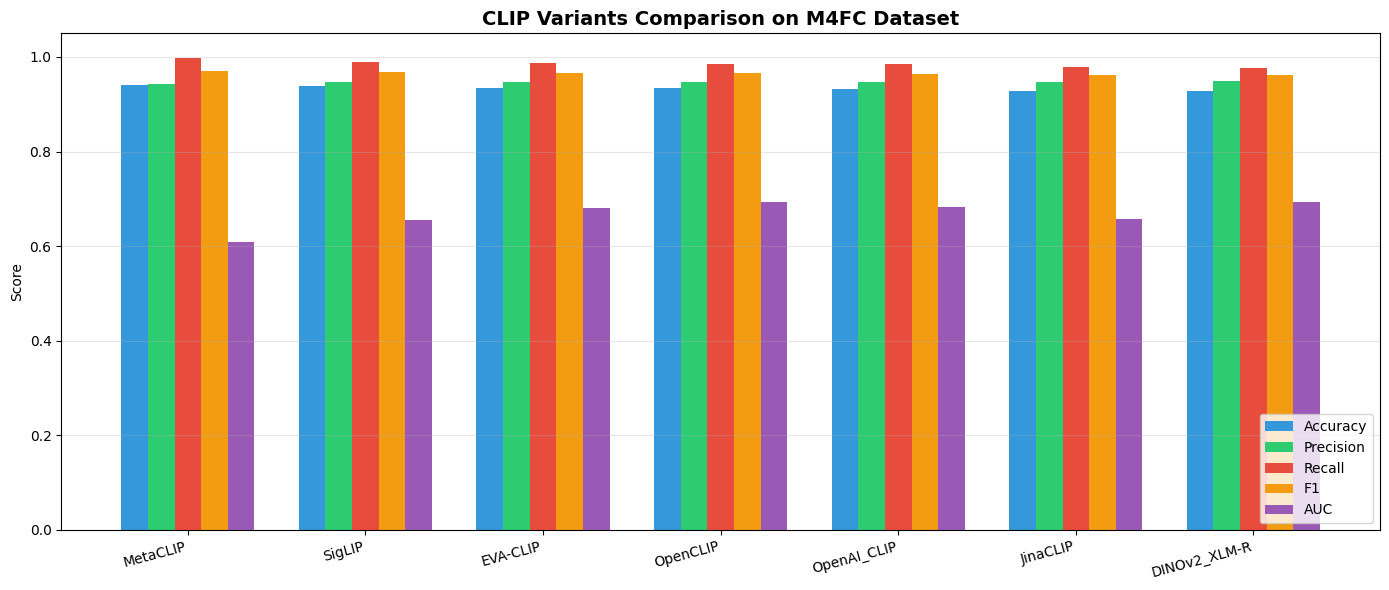

Comparison chart saved.


In [30]:
results_data = []
for name, res in all_results.items():
    results_data.append({
        'Model': name,
        'Accuracy': round(res.get('accuracy', 0.0), 4),
        'Precision': round(res.get('precision', 0.0), 4),
        'Recall': round(res.get('recall', 0.0), 4),
        'F1 Score': round(res.get('f1', 0.0), 4),
        'AUC': round(res.get('auc', 0.0), 4)
    })

summary_df = pd.DataFrame(results_data).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("FINAL CLIP VARIANTS COMPARISON")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# Save tabular comparison report
summary_path = "../reports/clip/metrics/CLIP_Comparison_Report.txt"
os.makedirs(os.path.dirname(summary_path), exist_ok=True)
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("MULTIMODAL FAKE NEWS DETECTION: CLIP VARIANTS COMPARISON\n")
    f.write("="*70 + "\n\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nNote: Evaluated under identical 70/15/15 stratified splits.\n")
print(f"Comparison report saved to {summary_path}")

# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(summary_df))
width = 0.15

ax.bar(x - 2*width, summary_df['Accuracy'], width, label='Accuracy', color='#3498db')
ax.bar(x - width, summary_df['Precision'], width, label='Precision', color='#2ecc71')
ax.bar(x, summary_df['Recall'], width, label='Recall', color='#e74c3c')
ax.bar(x + width, summary_df['F1 Score'], width, label='F1', color='#f39c12')
ax.bar(x + 2*width, summary_df['AUC'], width, label='AUC', color='#9b59b6')

ax.set_xticks(x)
ax.set_xticklabels(summary_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('CLIP Variants Comparison on M4FC Dataset', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/clip/figures/clip_comparison_summary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Comparison chart saved.")
